In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [27]:
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
if not os.path.exists('/content/drive/MyDrive/aurtism_training/aut_Recording_6.m4a.npy'):
    import mfcc_extract

In [29]:
# Load MFCC features
features_folder = "/content/drive/MyDrive/aurtism_training/features"
autistic_files = [f for f in os.listdir(features_folder) if f.startswith("aut_")]
non_autistic_files = [f for f in os.listdir(features_folder) if f.startswith("split-")]

In [30]:
print(len(autistic_files))
print(len(non_autistic_files))

19
17


In [31]:
# Define a function to load and pad/truncate MFCC data
def load_and_average_data(files, max_frames):
    data_list = []
    for file in files:
        data = np.load(os.path.join(features_folder, file))
        # print(data.shape)
        avg = np.mean(data, axis=1)  # Calculate row-wise average
        # avg = [avg[0],avg[2],avg[4]]
        data_list.append(avg)  # Append the averaged data to the list



    return np.stack(data_list, axis=0)

In [32]:
# Load and process autistic data
autistic_data = load_and_average_data(autistic_files, 20)

In [33]:
# Load and process non-autistic data
non_autistic_data = load_and_average_data(non_autistic_files, 20)

In [34]:
# Combine data and labels
X = np.vstack((autistic_data, non_autistic_data))
y = np.hstack((np.ones(autistic_data.shape[0]), np.zeros(non_autistic_data.shape[0])))

In [35]:
# Split data into train and test sets equally for both classes
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=50)

In [36]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

In [37]:
def train_and_evaluate_models(X_train, X_test, y_train, y_test):
    models = {
        "SVM": SVC(kernel='rbf', probability=True, random_state=42),
        "Naive Bayes": GaussianNB(),
        "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
        "ANN": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300, random_state=42)
    }

    results = []

    for name, model in models.items():
        print(f"\n🔹 Training {name} model...")
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        # Compute metrics
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

        print(f"{name} Accuracy: {acc:.4f}")
        print(f"{name} Precision: {prec:.4f}")
        print(f"{name} Recall: {rec:.4f}")
        print(f"{name} F1 Score: {f1:.4f}")

        # Save model
        joblib.dump(model, f'{name.lower().replace(" ", "_")}.pkl')

        results.append({
            'Model': name,
            'Accuracy': acc,
            'Precision': prec,
            'Recall': rec,
            'F1 Score': f1
        })

        # Confusion Matrix
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(5,4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title(f'{name} - Confusion Matrix')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.show()

    # Create a comparison DataFrame
    import pandas as pd
    results_df = pd.DataFrame(results)
    print("\n📊 Model Performance Summary:")
    display(results_df)

    # 📈 Plot Performance Comparison
    plt.figure(figsize=(10,6))
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
    for metric in metrics:
        plt.plot(results_df['Model'], results_df[metric], marker='o', label=metric)
    plt.title('Model Performance Comparison')
    plt.xlabel('Model')
    plt.ylabel('Score')
    plt.legend()
    plt.grid(True)
    plt.show()

    return results_df



🔹 Training SVM model...
SVM Accuracy: 0.3636
SVM Precision: 0.1322
SVM Recall: 0.3636
SVM F1 Score: 0.1939


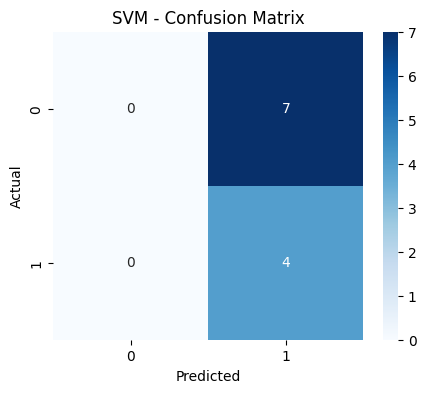


🔹 Training Naive Bayes model...
Naive Bayes Accuracy: 0.8182
Naive Bayes Precision: 0.8788
Naive Bayes Recall: 0.8182
Naive Bayes F1 Score: 0.8212


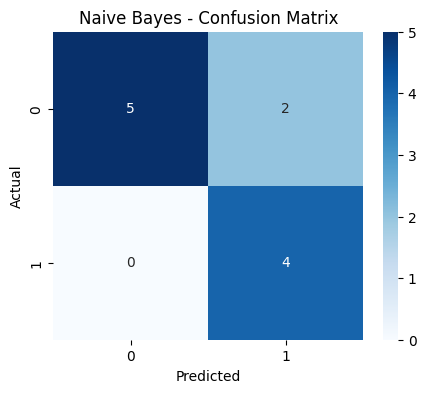


🔹 Training Random Forest model...
Random Forest Accuracy: 0.9091
Random Forest Precision: 0.9273
Random Forest Recall: 0.9091
Random Forest F1 Score: 0.9106


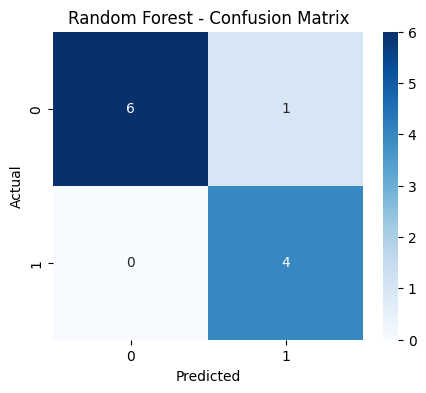


🔹 Training ANN model...
ANN Accuracy: 0.3636
ANN Precision: 0.1322
ANN Recall: 0.3636
ANN F1 Score: 0.1939


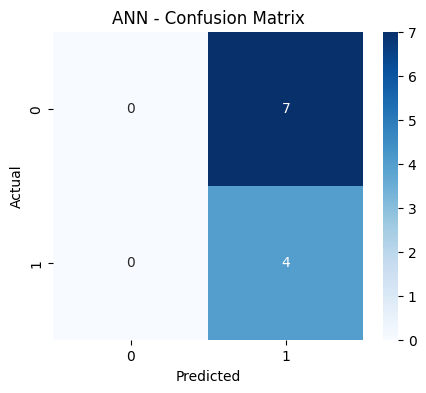


📊 Model Performance Summary:


,Model,Accuracy,Precision,Recall,F1 Score
0,SVM,0.363636,0.132231,0.363636,0.193939
1,Naive Bayes,0.818182,0.878788,0.818182,0.821212
2,Random Forest,0.909091,0.927273,0.909091,0.910645
3,ANN,0.363636,0.132231,0.363636,0.193939


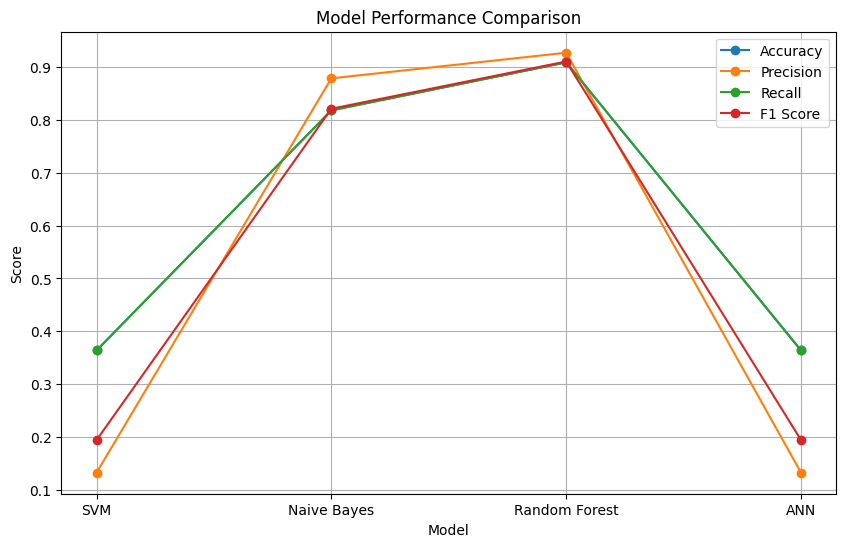

In [38]:
results_df = train_and_evaluate_models(X_train, X_test, y_train, y_test)